# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Daffa Rizqianaufal Maulidsyah
- **Email:** daffarizqii218@gmail.com
- **ID Dicoding:** daffa1212

## Menentukan Pertanyaan Bisnis

1. **Kategori produk apa yang menghasilkan revenue tertinggi, dan bagaimana tren revenue bulanannya selama 2017-2018?**  
   Pertanyaan ini spesifik pada kategori produk, dapat diukur dengan revenue, relevan untuk strategi merchandising, dan dibatasi pada periode 2017-2018.

2. **Sejauh mana keterlambatan pengiriman memengaruhi review pelanggan, dan state mana yang memiliki late delivery rate tertinggi selama 2017-2018?**  
   Pertanyaan ini spesifik pada hubungan delivery performance dan kepuasan pelanggan, dapat diukur dengan review score dan late rate, serta dapat ditindaklanjuti oleh tim operasional/logistik.

## Import Semua Packages/Library yang Digunakan

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path(".")

## Data Wrangling

### Gathering Data

In [4]:
customers_df = pd.read_csv(DATA_DIR / "customers_dataset.csv")
orders_df = pd.read_csv(DATA_DIR / "orders_dataset.csv")
order_items_df = pd.read_csv(DATA_DIR / "order_items_dataset.csv")
order_payments_df = pd.read_csv(DATA_DIR / "order_payments_dataset.csv")
order_reviews_df = pd.read_csv(DATA_DIR / "order_reviews_dataset.csv")
products_df = pd.read_csv(DATA_DIR / "products_dataset.csv")
category_translation_df = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

data_overview = pd.DataFrame({
    "dataset": [
        "customers", "orders", "order_items", "order_payments",
        "order_reviews", "products", "category_translation"
    ],
    "rows": [
        len(customers_df), len(orders_df), len(order_items_df),
        len(order_payments_df), len(order_reviews_df), len(products_df),
        len(category_translation_df)
    ],
    "columns": [
        customers_df.shape[1], orders_df.shape[1], order_items_df.shape[1],
        order_payments_df.shape[1], order_reviews_df.shape[1],
        products_df.shape[1], category_translation_df.shape[1]
    ]
})

display(data_overview)

,dataset,rows,columns
0,customers,99441,5
1,orders,99441,8
2,order_items,112650,7
3,order_payments,103886,5
4,order_reviews,99224,7
5,products,32951,9
6,category_translation,71,2


**Insight:**
- Dataset yang digunakan terdiri dari beberapa tabel utama: pelanggan, order, item order, pembayaran, review, produk, dan translasi kategori.
- Struktur ini memungkinkan analisis end-to-end dari transaksi, revenue, hingga pengalaman pelanggan setelah barang diterima.

### Assessing Data

In [5]:
missing_summary = pd.DataFrame({
    "orders_missing": orders_df.isna().sum(),
    "products_missing": products_df.isna().sum(),
    "reviews_missing": order_reviews_df.isna().sum()
}).fillna(0).astype(int)

duplicate_summary = pd.DataFrame({
    "dataset": ["customers", "orders", "order_items", "order_payments", "order_reviews", "products"],
    "duplicate_rows": [
        customers_df.duplicated().sum(),
        orders_df.duplicated().sum(),
        order_items_df.duplicated().sum(),
        order_payments_df.duplicated().sum(),
        order_reviews_df.duplicated().sum(),
        products_df.duplicated().sum()
    ]
})

print("Ringkasan missing values (kolom dengan nilai > 0):")
display(missing_summary[(missing_summary > 0).any(axis=1)])

print("Ringkasan duplicate rows:")
display(duplicate_summary)

print("Distribusi status order:")
display(orders_df["order_status"].value_counts().to_frame("count"))

Ringkasan missing values (kolom dengan nilai > 0):


,orders_missing,products_missing,reviews_missing
order_approved_at,160,0,0
order_delivered_carrier_date,1783,0,0
order_delivered_customer_date,2965,0,0
product_category_name,0,610,0
product_description_lenght,0,610,0
product_height_cm,0,2,0
product_length_cm,0,2,0
product_name_lenght,0,610,0
product_photos_qty,0,610,0
product_weight_g,0,2,0


Ringkasan duplicate rows:


,dataset,duplicate_rows
0,customers,0
1,orders,0
2,order_items,0
3,order_payments,0
4,order_reviews,0
5,products,0


Distribusi status order:


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


**Insight:**
- Missing value terbesar ada pada `order_delivered_customer_date` dan `order_delivered_carrier_date`, yang wajar karena tidak semua order berstatus delivered.
- Kolom review comment juga banyak kosong karena tidak semua pelanggan menuliskan komentar, meskipun tetap memberi rating.
- Tidak ditemukan duplicate row penuh pada tabel utama sehingga fokus cleaning diarahkan pada penyesuaian tipe data, penggabungan tabel, dan penanganan kategori produk yang kosong.

### Cleaning Data

In [6]:
date_columns_orders = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_columns_orders:
    orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

order_reviews_df["review_creation_date"] = pd.to_datetime(order_reviews_df["review_creation_date"], errors="coerce")
order_reviews_df["review_answer_timestamp"] = pd.to_datetime(order_reviews_df["review_answer_timestamp"], errors="coerce")
order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"], errors="coerce")

products_df = products_df.merge(category_translation_df, on="product_category_name", how="left")
products_df["product_category_name_english"] = (
    products_df["product_category_name_english"]
    .fillna(products_df["product_category_name"])
    .fillna("unknown")
)

order_items_enriched_df = order_items_df.merge(
    products_df[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)
order_items_enriched_df["product_category_name_english"] = order_items_enriched_df["product_category_name_english"].fillna("unknown")
order_items_enriched_df["item_total"] = order_items_enriched_df["price"] + order_items_enriched_df["freight_value"]

order_value_df = order_items_enriched_df.groupby("order_id").agg(
    item_count=("order_item_id", "count"),
    revenue=("price", "sum"),
    freight=("freight_value", "sum")
).reset_index()

primary_category_df = (
    order_items_enriched_df.groupby(["order_id", "product_category_name_english"])["item_total"]
    .sum()
    .reset_index()
    .sort_values(["order_id", "item_total"], ascending=[True, False])
    .drop_duplicates("order_id")
    .rename(columns={"product_category_name_english": "primary_category"})
    [["order_id", "primary_category"]]
)

payments_agg_df = order_payments_df.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max")
).reset_index()

reviews_agg_df = order_reviews_df.groupby("order_id").agg(
    review_score=("review_score", "mean")
).reset_index()

all_df = (
    orders_df.merge(customers_df, on="customer_id", how="left")
    .merge(order_value_df, on="order_id", how="left")
    .merge(payments_agg_df, on="order_id", how="left")
    .merge(reviews_agg_df, on="order_id", how="left")
    .merge(primary_category_df, on="order_id", how="left")
)

main_df = all_df[
    (all_df["order_status"] == "delivered") &
    (all_df["order_purchase_timestamp"] >= "2017-01-01")
].copy()

main_df["delivery_time_days"] = (
    main_df["order_delivered_customer_date"] - main_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

main_df["delivery_delay_days"] = (
    main_df["order_delivered_customer_date"] - main_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

main_df["is_late"] = main_df["delivery_delay_days"] > 0
main_df["purchase_month"] = main_df["order_purchase_timestamp"].dt.to_period("M").astype(str)
main_df["purchase_year"] = main_df["order_purchase_timestamp"].dt.year

main_df["delay_bucket"] = pd.cut(
    main_df["delivery_delay_days"],
    bins=[-np.inf, -10, 0, 5, np.inf],
    labels=[
        "Lebih cepat >10 hari",
        "Tepat / lebih cepat <=10 hari",
        "Terlambat 1-5 hari",
        "Terlambat >5 hari"
    ]
)

print("Ukuran dataset setelah cleaning:", main_df.shape)
display(main_df.head())

Ukuran dataset setelah cleaning: (96211, 25)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,item_count,revenue,freight,payment_value,payment_installments,review_score,primary_category,delivery_time_days,delivery_delay_days,is_late,purchase_month,purchase_year,delay_bucket
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,29.99,8.72,38.71,1.00,4.00,housewares,8.44,-7.11,False,2017-10,2017,Tepat / lebih cepat <=10 hari
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,118.70,22.76,141.46,1.00,4.00,perfumery,13.78,-5.36,False,2018-07,2018,Tepat / lebih cepat <=10 hari
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,159.90,19.22,179.12,3.00,5.00,auto,9.39,-17.25,False,2018-08,2018,Lebih cepat >10 hari
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.00,45.00,27.20,72.20,1.00,5.00,pet_shop,13.21,-12.98,False,2017-11,2017,Lebih cepat >10 hari
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.00,19.90,8.72,28.62,1.00,5.00,stationery,2.87,-9.24,False,2018-02,2018,Tepat / lebih cepat <=10 hari


**Insight:**
- Analisis utama difokuskan pada order `delivered` mulai 2017 agar metrik pengiriman dan review dapat dihitung secara konsisten.
- Kategori produk yang kosong diisi sebagai `unknown` agar tidak hilang saat agregasi.
- Setelah penggabungan tabel, tersedia metrik turunan penting seperti `delivery_time_days`, `delivery_delay_days`, `is_late`, dan `purchase_month`.

## Exploratory Data Analysis (EDA)

### Explore hubungan penjualan, pengiriman, dan kepuasan pelanggan

In [7]:
items_orders_df = order_items_enriched_df.merge(
    orders_df[["order_id", "order_status", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)
items_orders_df = items_orders_df[
    (items_orders_df["order_status"] == "delivered") &
    (items_orders_df["order_purchase_timestamp"] >= "2017-01-01")
].copy()
items_orders_df["purchase_month"] = items_orders_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

category_summary_df = (
    items_orders_df.groupby("product_category_name_english")
    .agg(
        total_revenue=("item_total", "sum"),
        total_orders=("order_id", "nunique"),
        avg_item_price=("price", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

delay_review_df = (
    main_df.groupby("delay_bucket", observed=False)
    .agg(
        avg_review=("review_score", "mean"),
        order_count=("order_id", "nunique"),
        avg_delivery_days=("delivery_time_days", "mean")
    )
    .reset_index()
)

state_delay_df = (
    main_df.groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", "sum"),
        avg_review=("review_score", "mean")
    )
)
state_delay_df["late_rate"] = state_delay_df["late_orders"] / state_delay_df["total_orders"]
state_delay_df = state_delay_df[state_delay_df["total_orders"] >= 500].sort_values("late_rate", ascending=False)

snapshot_date = main_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
rfm_df = (
    main_df.groupby("customer_unique_id")
    .agg(
        recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("payment_value", "sum")
    )
    .reset_index()
)

print("Top 10 kategori berdasarkan total revenue:")
display(category_summary_df.head(10))

print("Review berdasarkan bucket keterlambatan:")
display(delay_review_df)

print("State dengan late rate tertinggi (minimal 500 order):")
display(state_delay_df.head(10))

Top 10 kategori berdasarkan total revenue:


,total_revenue,total_orders,avg_item_price
product_category_name_english,,,
health_beauty,"1,407,759.78",8610,130.50
watches_gifts,"1,261,539.41",5491,198.71
bed_bath_table,"1,224,602.68",9267,93.46
sports_leisure,"1,115,766.15",7513,113.24
computers_accessories,"1,031,861.93",6518,116.36
furniture_decor,"873,430.57",6258,87.24
housewares,"756,849.71",5734,90.57
cool_stuff,"690,444.01",3552,164.15
auto,"668,103.48",3802,139.84


Review berdasarkan bucket keterlambatan:


,delay_bucket,avg_review,order_count,avg_delivery_days
0,Lebih cepat >10 hari,4.32,56949,9.98
1,Tepat / lebih cepat <=10 hari,4.24,31432,12.45
2,Terlambat 1-5 hari,3.46,3613,22.09
3,Terlambat >5 hari,1.79,4209,39.58


State dengan late rate tertinggi (minimal 500 order):


,total_orders,late_orders,avg_review,late_rate
customer_state,,,,
MA,713,140,3.83,0.20
CE,1273,196,3.94,0.15
BA,3253,457,3.93,0.14
RJ,12310,1664,3.97,0.14
PA,942,117,3.91,0.12
ES,1992,244,4.08,0.12
MS,701,81,4.16,0.12
PB,516,57,4.07,0.11
PE,1587,172,4.08,0.11


**Insight:**
- Revenue terbesar berasal dari kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table`.
- Review score turun tajam ketika pengiriman terlambat, terutama untuk order yang terlambat lebih dari 5 hari.
- Beberapa state memiliki late rate yang lebih tinggi daripada wilayah lain, sehingga berpotensi menjadi prioritas evaluasi operasional.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan revenue tertinggi, dan bagaimana tren revenue bulanannya selama 2017-2018?

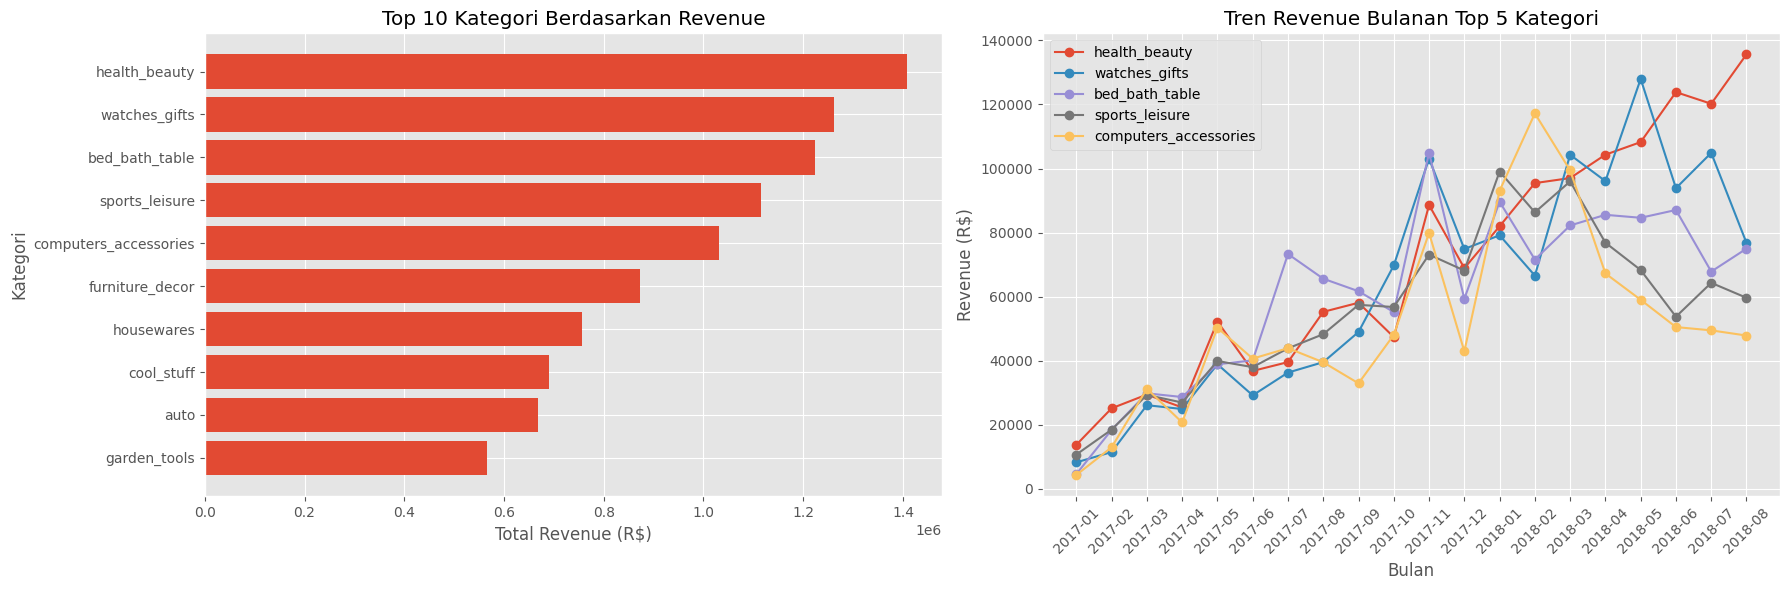

,product_category_name_english,total_revenue,total_orders
0,health_beauty,"1,407,759.78",8610
1,watches_gifts,"1,261,539.41",5491
2,bed_bath_table,"1,224,602.68",9267
3,sports_leisure,"1,115,766.15",7513
4,computers_accessories,"1,031,861.93",6518
5,furniture_decor,"873,430.57",6258
6,housewares,"756,849.71",5734
7,cool_stuff,"690,444.01",3552
8,auto,"668,103.48",3802
9,garden_tools,"565,680.49",3443


In [8]:
top_categories_df = category_summary_df.head(10).reset_index()

top_5_categories = category_summary_df.head(5).index.tolist()
monthly_category_df = (
    items_orders_df[items_orders_df["product_category_name_english"].isin(top_5_categories)]
    .groupby(["purchase_month", "product_category_name_english"])["item_total"]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(top_categories_df["product_category_name_english"][::-1], top_categories_df["total_revenue"][::-1])
axes[0].set_title("Top 10 Kategori Berdasarkan Revenue")
axes[0].set_xlabel("Total Revenue (R$)")
axes[0].set_ylabel("Kategori")

for category in top_5_categories:
    subset = monthly_category_df[monthly_category_df["product_category_name_english"] == category]
    axes[1].plot(subset["purchase_month"], subset["item_total"], marker="o", label=category)

axes[1].set_title("Tren Revenue Bulanan Top 5 Kategori")
axes[1].set_xlabel("Bulan")
axes[1].set_ylabel("Revenue (R$)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

display(top_categories_df[["product_category_name_english", "total_revenue", "total_orders"]])

### Pertanyaan 2: Sejauh mana keterlambatan pengiriman memengaruhi review pelanggan, dan state mana yang memiliki late delivery rate tertinggi selama 2017-2018?

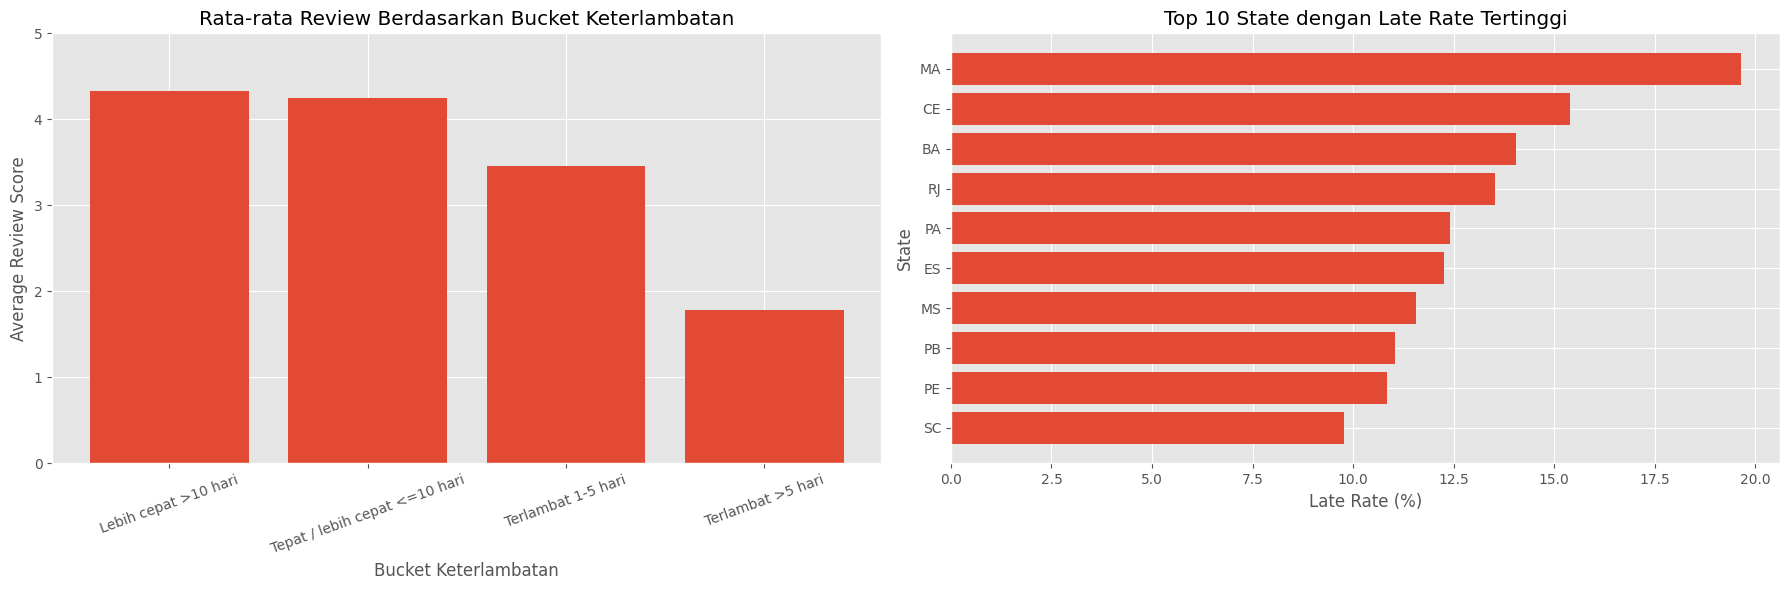

,delay_bucket,avg_review,order_count,avg_delivery_days
0,Lebih cepat >10 hari,4.32,56949,9.98
1,Tepat / lebih cepat <=10 hari,4.24,31432,12.45
2,Terlambat 1-5 hari,3.46,3613,22.09
3,Terlambat >5 hari,1.79,4209,39.58


,customer_state,total_orders,late_rate,avg_review
0,MA,713,0.20,3.83
1,CE,1273,0.15,3.94
2,BA,3253,0.14,3.93
3,RJ,12310,0.14,3.97
4,PA,942,0.12,3.91
5,ES,1992,0.12,4.08
6,MS,701,0.12,4.16
7,PB,516,0.11,4.07
8,PE,1587,0.11,4.08
9,SC,3537,0.10,4.13


In [9]:
state_delay_top10_df = state_delay_df.head(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(delay_review_df["delay_bucket"].astype(str), delay_review_df["avg_review"])
axes[0].set_title("Rata-rata Review Berdasarkan Bucket Keterlambatan")
axes[0].set_xlabel("Bucket Keterlambatan")
axes[0].set_ylabel("Average Review Score")
axes[0].set_ylim(0, 5)
axes[0].tick_params(axis="x", rotation=20)

axes[1].barh(state_delay_top10_df["customer_state"][::-1], (state_delay_top10_df["late_rate"][::-1] * 100))
axes[1].set_title("Top 10 State dengan Late Rate Tertinggi")
axes[1].set_xlabel("Late Rate (%)")
axes[1].set_ylabel("State")

plt.tight_layout()
plt.show()

display(delay_review_df)
display(state_delay_top10_df[["customer_state", "total_orders", "late_rate", "avg_review"]])

**Insight:**
- `health_beauty` menjadi kategori dengan revenue tertinggi, diikuti `watches_gifts` dan `bed_bath_table`, sehingga ketiganya layak menjadi fokus strategi inventori dan promosi.
- Top category menunjukkan pola kenaikan yang relatif kuat pada periode 2017-2018, terutama saat momentum belanja akhir tahun dan awal 2018.
- Order yang terlambat lebih dari 5 hari hanya memperoleh rata-rata review sekitar 1.8, jauh di bawah order yang datang tepat waktu atau lebih cepat (di atas 4.2).
- State dengan late rate tertinggi perlu diprioritaskan untuk investigasi jaringan logistik, SLA mitra, atau kapasitas last-mile delivery.

## Analisis Lanjutan (Opsional)

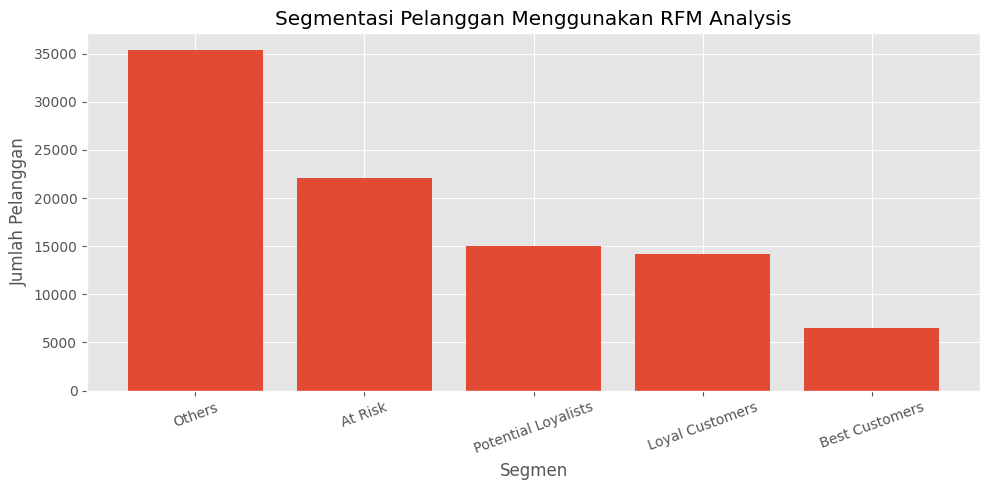

,segment,customer_count,share_pct
0,Others,35340,37.96
1,At Risk,22079,23.71
2,Potential Loyalists,14985,16.09
3,Loyal Customers,14206,15.26
4,Best Customers,6494,6.97


In [10]:
rfm_df["R_score"] = pd.qcut(rfm_df["recency"], 5, labels=[5, 4, 3, 2, 1], duplicates="drop").astype(int)
rfm_df["F_score"] = pd.qcut(rfm_df["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df["M_score"] = pd.qcut(rfm_df["monetary"], 5, labels=[1, 2, 3, 4, 5], duplicates="drop").astype(int)

def map_segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Best Customers"
    elif row["R_score"] >= 3 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] >= 4 and row["F_score"] <= 2:
        return "Potential Loyalists"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    else:
        return "Others"

rfm_df["segment"] = rfm_df.apply(map_segment, axis=1)

rfm_segment_summary_df = (
    rfm_df["segment"]
    .value_counts()
    .rename_axis("segment")
    .reset_index(name="customer_count")
)
rfm_segment_summary_df["share_pct"] = (
    rfm_segment_summary_df["customer_count"] / rfm_segment_summary_df["customer_count"].sum() * 100
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(rfm_segment_summary_df["segment"], rfm_segment_summary_df["customer_count"])
ax.set_title("Segmentasi Pelanggan Menggunakan RFM Analysis")
ax.set_xlabel("Segmen")
ax.set_ylabel("Jumlah Pelanggan")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

display(rfm_segment_summary_df)

## Conclusion

- **Kesimpulan pertanyaan 1:** Kategori dengan revenue tertinggi selama periode analisis adalah `health_beauty`, disusul `watches_gifts` dan `bed_bath_table`. Artinya, kategori-kategori tersebut dapat menjadi prioritas untuk promosi, pengelolaan stok, dan optimasi katalog.
- **Kesimpulan pertanyaan 2:** Keterlambatan pengiriman memiliki hubungan negatif yang kuat dengan review pelanggan. Semakin terlambat pesanan diterima, semakin rendah review score yang diberikan. Beberapa state juga memiliki late delivery rate yang lebih tinggi, sehingga membutuhkan perhatian operasional lebih lanjut.
- **Kesimpulan analisis lanjutan:** RFM menunjukkan bahwa basis pelanggan tidak homogen. Terdapat kelompok `Best Customers`, `Loyal Customers`, dan `At Risk` yang dapat diperlakukan dengan strategi retensi dan promosi yang berbeda.